<p></p>
<br />
<div id="sec_reg" style="direction:rtl;line-height:300%;">
	<font face="XB Zar" size=3>
        <font color=#0f6d02 size=5>
           اضافه‌کردن کتابخانه‌های مورد نیاز
        </font>
		<p></p>
		<hr>
	</font>
</div>

In [1]:
import sklearn
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split

<p></p>
<br />
<div id="sec_madules" style="direction:rtl;line-height:300%;">
	<font face="XB Zar" size=3>
        <font color=#0f6d02 size=5>
            خواندن داده
        </font>
		<p></p>
		<hr>
	</font>
</div>

In [11]:
df = pd.read_csv('wbc.csv')

In [12]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


<div id="sec_madules" style="direction:rtl;line-height:300%;">
	<font face="XB Zar" size=3>
       دو ویژگی
        <code>radius_mean</code> 
و
        <code>concave points_mean</code>
را به عنوان داده برای دادن به مدل جدا می‌کنیم.
هم‌چنین
        <code>diagnosis</code> 
که خوش‌خیم یا بدخیم بودن تومور را مشخص می‌کند را نیز تبدیل به مقادیر عددی می‌کنیم تا برای مدل قابل فهم باشد.
	</font>
</div>

In [15]:
X = df[['radius_mean','concave points_mean']].values
df['diagnosis'].map({'B':0,'M':1})
Y = df['diagnosis']

<p></p>
<br />
<div id="sec_madules" style="direction:rtl;line-height:300%;">
	<font face="XB Zar" size=3>
        <font color=#0f6d02 size=5>
            جدا کردن داده‌ی آموزش و آزمون
        </font>
		<p></p>
		<hr>
        تابع
        <code>train_test_split</code>
         با گرفتن
        <code>test_size</code>
        ، به صورت تعداد یا نسبت ورودی و خروجی،
         مدل را به دو قسمت آموزش
        (<code>train</code>) 
        و آزمون
        (<code>test</code>) 
        تقسیم می‌کند.
ولی انتخاب داده‌ها برای قرارگیری در قسمت آموزش و آزمون به صورت تصادفی است که با دادن
        <code>random_state</code>
        می‌توانیم حالت تصادف آن را تعیین کنیم تا همه افرادی که این کد‌ها را اجرا می‌کنند نتایج یکسانی ببینند.
	</font>
</div>

In [17]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,stratify = Y,random_state = 1)

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

<p></p>
<br />
<div id="sec_madules" style="direction:rtl;line-height:300%;">
	<font face="XB Zar" size=3>
        <font color=#0f6d02 size=5>
            آموزش مدل
        </font>
		<p></p>
		<hr>
        مدل را برای تعداد همسایگی‌های متفاوت $k$ که در آرایه <code>K</code> قرار دارند آموزش می‌دهیم. سپس دقت هرکدام را اندازه‌گیری می‌کنیم و در آرایه‌ی <code>acc</code> می‌ریزیم.
        <ul>
        <li>
             تابع <code>fit</code> مدل را برای $X$ و $Y$ داده شده به آن آموزش می‌دهد.
        </li>
        <li>
            حال می‌توان با دادن یک دسته ورودی ($X$) با استفاده از تابع <code>predict</code> پیش‌بینی مدل برای آنها را بدست آورد.
        </li>
        <li>
             تابع <code>accuracy_score</code> با گرفتن خروجی درست و خروجی پیش‌بینی شده توسط مدل دقت مدل را برمی‌گرداند.
        </li>
        </ul>
	</font>
</div>

In [19]:
K = [2,3,4,5,6,7,8,9,10]
acc = []
for k in K:
    knn = KNeighborsClassifier(n_neighbors= k)
    knn.fit(X_train,Y_train)
    y_pred_knn = knn.predict(X_test)
    acc.append(accuracy_score(Y_test,y_pred_knn))

<p></p>
<br />
<div id="sec_madules" style="direction:rtl;line-height:300%;">
	<font face="XB Zar" size=3>
        <font color=#0f6d02 size=5>
            رسم نمودار دقت
        </font>
		<p></p>
		<hr>
        حال نمودار دقت در برابر تعداد همسایگی($k$) را رسم می‌کنیم تا ببینیم مدل با چه تعدادی از همسایگی روی این داده بهتر عمل می‌کند.
	</font>
</div>

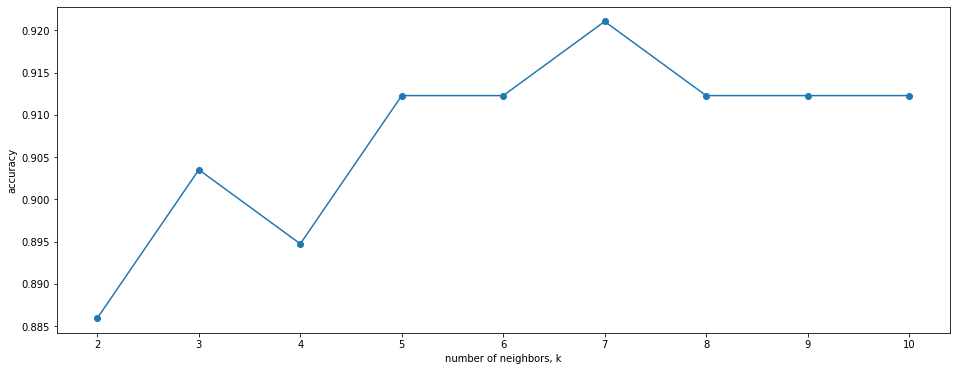

In [20]:
# Plot k's vs inertias
plt.figure(figsize = (16,6))
plt.plot(K, acc, '-o')
plt.xlabel('number of neighbors, k')
plt.ylabel('accuracy')
plt.xticks(K)
plt.show()